In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tunguz/online-retail")

print("Path to dataset files:", path)
df = pd.read_csv(path + '/' + os.listdir(path)[0], encoding='latin1')
df.shape

100%|██████████| 7.13M/7.13M [00:00<00:00, 83.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tunguz/online-retail/versions/1


(541909, 8)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# 주문 가격 피쳐 생성
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [7]:
# 'InvoiceDate' 컬럼을 이용하여 주중과 주말을 구분
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# 'InvoiceDate' 컬럼 이용하여 판매 월 추출
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"].astype(str))
df["InvoiceMonth"] = df["InvoiceDate"].dt.month

/tmp/ipython-input-3844768752.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     541909 non-null  object        
 1   StockCode     541909 non-null  object        
 2   Description   540455 non-null  object        
 3   Quantity      541909 non-null  int64         
 4   InvoiceDate   541909 non-null  datetime64[ns]
 5   UnitPrice     541909 non-null  float64       
 6   CustomerID    406829 non-null  float64       
 7   Country       541909 non-null  object        
 8   TotalPrice    541909 non-null  float64       
 9   DayOfWeek     541909 non-null  int32         
 10  InvoiceMonth  541909 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4)
memory usage: 41.3+ MB


In [10]:
df.isna().mean()

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.002683
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,0.249267
Country,0.000000
TotalPrice,0.000000
DayOfWeek,0.000000


CustomerID는 컬럼 없애도 될 거 같음

고유값이기도 하고 무엇보다 결측치 비율도 좀 되고, 고객분석 관련 미션은 없음

Description도 마찬가지.

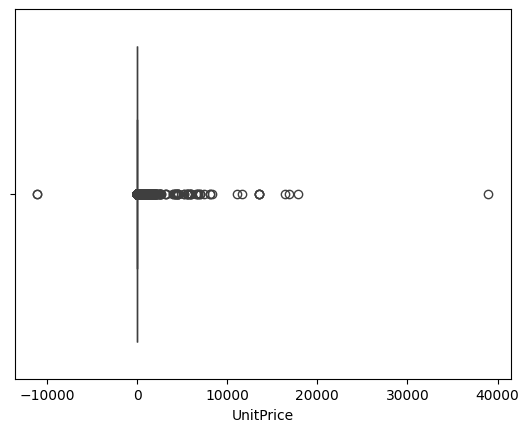

In [11]:
sns.boxplot(x=df['UnitPrice']);
plt.show()

In [12]:
df['StockCode'].value_counts()

,count
StockCode,
85123A,2313
22423,2203
85099B,2159
47566,1727
20725,1639
...,...
85179a,1
23617,1
90214U,1


UnitPrice(단위 가격) 값이 음수(describe min -11062.06)인 건 발견했고 제거 결정

극단값(describe max: 38970)에 대해서는 StockCode의 value_counts가 1건인 경우를 발견했지만, 극단값을 제거하지 않고 모델에 그대로 데이터 입력 시 극단값으로 인해 결과가 왜곡될 가능성이 높아서 제거 결정

In [13]:
df[['UnitPrice','Quantity','TotalPrice']].describe()

,UnitPrice,Quantity,TotalPrice
count,541909.000000,541909.000000,541909.000000
mean,4.611114,9.552250,17.987795
std,96.759853,218.081158,378.810824
min,-11062.060000,-80995.000000,-168469.600000
25%,1.250000,1.000000,3.400000
50%,2.080000,3.000000,9.750000
75%,4.130000,10.000000,17.400000
max,38970.000000,80995.000000,168469.600000


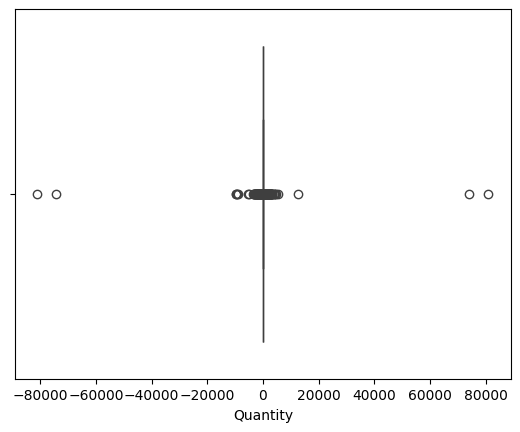

In [14]:
sns.boxplot(x=df['Quantity']);
plt.show()

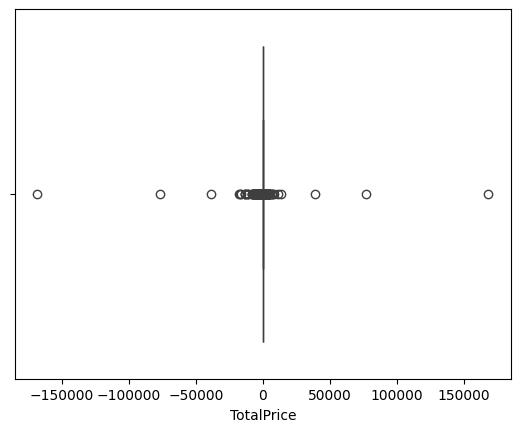

In [15]:
sns.boxplot(x=df['TotalPrice']);
plt.show()

UnitPrice,Quantity,TotalPrice 세 컬럼의 기초 통계를 봤을때 다들 음수와 극단값 때문에 표준편차도 커진 상황이고, 박스플롯까지 같이 봤을 때 정상거래(Q1~Q3)는 매우 좁은 범위에 많은 양의 데이터가 몰려 있는 것으로 보임

또한 Quantity와 TotalPrice 박스플롯을 봤을 때 극단값이 음수와 양수 대칭으로 보이는 현상은 같은 비싼 제품을 잘못 구매했다가 반품한 것으로 추정되고, 역시나 극단값을 그대로 둔 채로 모델에 입력하면 결과가 왜곡될 가능성이 높아서 제거 결정

Quantity 극단값 -60000 이하, 60000 이상
TotalPrice은 UnitPrice와 TotalPrice 의 곱인 파생변수니까 UnitPrice와 TotalPrice만 데이터 정제하고 나면, TotalPrice도 극단값 제거될 거라고 예상

In [16]:
pd.crosstab((df['Quantity']<0), df['InvoiceNo'].astype(str).str.startswith('C'))

InvoiceNo,False,True
Quantity,,
False,531285,0
True,1336,9288


5번 미션에서 IsReturn 컬럼 생성하기 전에, 반품기준에 맞게 표기가 제대로 된 건지 확인

Quantity 값이 0 미만 이면서, InvoiceNo 값이 'C'로 시작하는게 9,288건(정상처리된 반품 건)

근데, Quantity 값이 0 이상 이면서, InvoiceNo 값이 'C'로 시작하지 않는 값은 반품이 아닌데 수량이 음수인 이상치(표기 오류)라고 봐서,

InvoiceNo 컬럼을 기준으로 반품 여부를 판단하는 게 맞다고 정의하고, 이상치(표기 오류)를 제거 결정(1336건은 전체의 약 0.25%밖에)

In [17]:
df = df.drop(columns=['CustomerID'])
df = df.drop(columns=['Description'])

df = df[df['UnitPrice'] > 0]
df = df[df['UnitPrice'] < 30000]

df = df[(df['Quantity'] > -60000) & (df['Quantity'] < 60000)]

# InvoiceNo가 'C' 시작이면 반품.
df['IsReturn'] = df['InvoiceNo'].astype(str).str.startswith('C').astype(int)
# 수량이 음수인데 반품 코드가 아닌 사례 처리
df = df[~((df['Quantity'] < 0) & (df['IsReturn'] == 0))]

In [18]:
df[['UnitPrice','Quantity','TotalPrice']].describe()

,UnitPrice,Quantity,TotalPrice
count,539387.000000,539387.000000,539387.000000
mean,4.601431,9.845997,18.185166
std,78.340043,40.689749,116.474335
min,0.001000,-9360.000000,-17836.460000
25%,1.250000,1.000000,3.750000
50%,2.080000,3.000000,9.840000
75%,4.130000,10.000000,17.400000
max,17836.460000,4800.000000,38970.000000


결측치 컬럼, 이상치, 극단값 정도만 정제된 상황

## 1. 모집단과 표본 집단의 TotalPrice를 비교해 주세요.

* 데이터셋에서 무작위로 1000개의 표본을 추출하세요.
* 추출된 표본과 전체 데이터셋의 'TotalPrice'에 대해 평균과 표준편차를 비교해주세요.  
* 중심극한정리를 사용해 모집단과 표본의 차이를 설명해주세요.

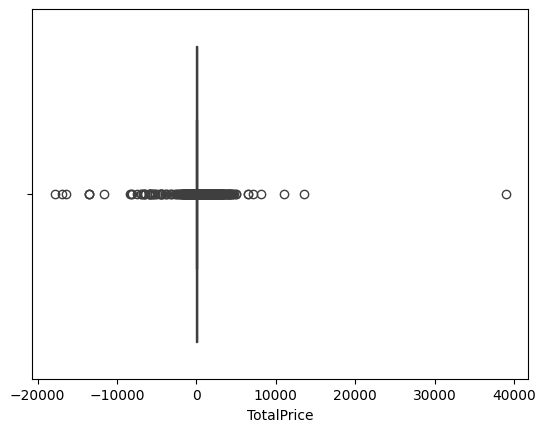

In [19]:
sns.boxplot(x=df['TotalPrice']);
plt.show()

모집단 vs 표본 비교
모집단 평균: 18.1852
모집단 표준편차: 116.4743
표본 평균: 19.2531
표본 표준편차: 57.3390




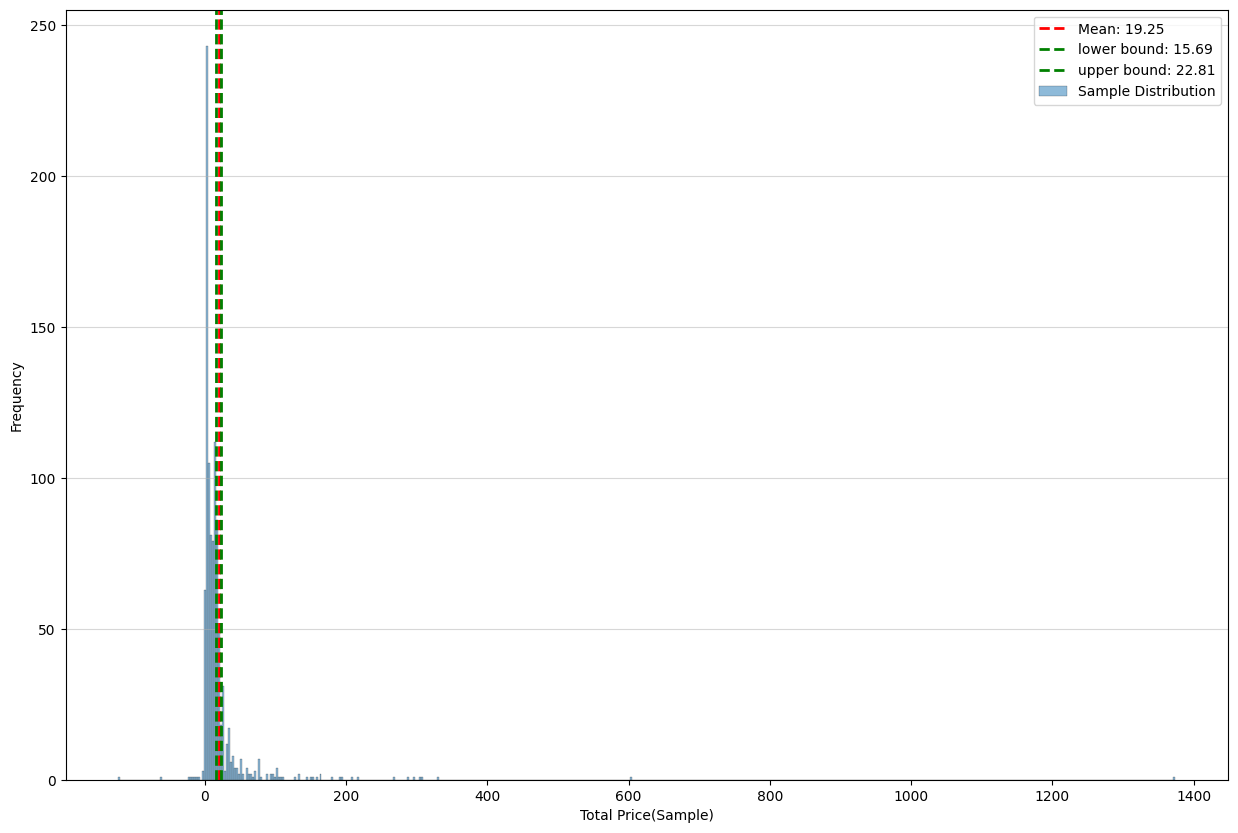


--- 표본 데이터 분석 결과 ---
표본 크기: 1000
표본 평균: 19.25
표본 표준편차: 57.34

추정된 95% 신뢰구간: [15.69, 22.81]
--- 95% 신뢰구간 추정 결과 ---
실제 모평균: 18.18516585308879
실제 모표준편차: 116.47433473299635

추정 성공! 신뢰구간이 실제 모평균을 포함했습니다.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

total = df['TotalPrice']

total_mean = total.mean()
total_std = total.std()

sample = total.sample(1000, random_state=42)
sample_mean = sample.mean()
sample_std = sample.std()

print("모집단 vs 표본 비교")
print(f"모집단 평균: {total_mean:.4f}")
print(f"모집단 표준편차: {total_std:.4f}")
print(f"표본 평균: {sample_mean:.4f}")
print(f"표본 표준편차: {sample_std:.4f}")
print("\n")

confidence_level = 0.95

n = len(sample)
dof = n - 1

t_value = stats.t.ppf((1 + confidence_level) / 2, df=dof)

std_error = sample_std / np.sqrt(n)

margin_of_error = t_value * std_error

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

plt.figure(figsize=(15, 10))

sns.histplot(sample, alpha=0.5, label='Sample Distribution')

plt.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {sample_mean:.2f}')
plt.axvline(lower_bound, color='green', linestyle='--', linewidth=2, label=f'lower bound: {lower_bound:.2f}')
plt.axvline(upper_bound, color='green', linestyle='--', linewidth=2, label=f'upper bound: {upper_bound:.2f}')

plt.xlabel('Total Price(Sample)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.5)

plt.show()

print("\n--- 표본 데이터 분석 결과 ---")
print(f"표본 크기: {n}")
print(f"표본 평균: {sample_mean:.2f}")
print(f"표본 표준편차: {sample_std:.2f}\n")
print(f"추정된 95% 신뢰구간: [{lower_bound:.2f}, {upper_bound:.2f}]")

print("--- 95% 신뢰구간 추정 결과 ---")
print(f"실제 모평균: {total_mean}")
print(f"실제 모표준편차: {total_std}")

if lower_bound <= total_mean <= upper_bound:
    print("\n추정 성공! 신뢰구간이 실제 모평균을 포함했습니다.")
else:
    print("\n추정 실패! 신뢰구간이 실제 모평균을 포함하지 못했습니다.")

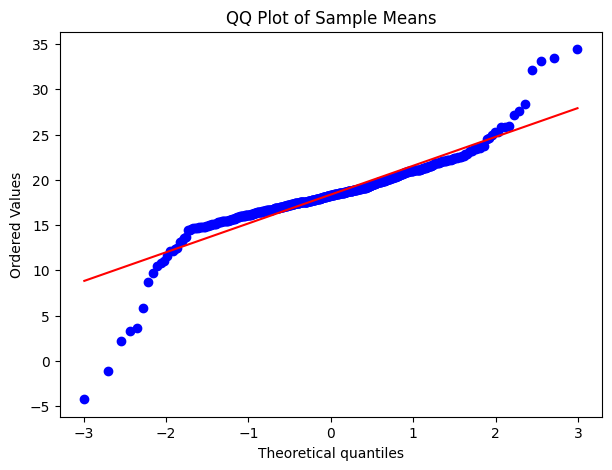

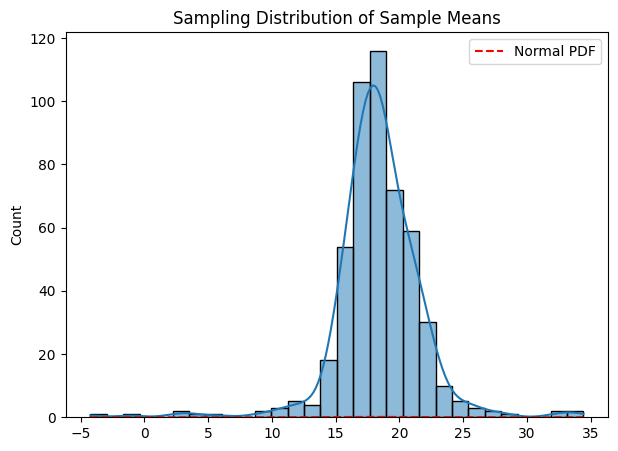

In [21]:
from scipy.stats import norm, probplot

means = []

for _ in range(500):  # 500번 평균 뽑기(복원추출)
    samp = total.sample(1000, replace=True)
    means.append(samp.mean())

means = pd.Series(means)

# QQ plot
plt.figure(figsize=(7,5))
probplot(means, dist="norm", plot=plt)
plt.title("QQ Plot of Sample Means")
plt.show()

# Histogram + Normal distribution
plt.figure(figsize=(7,5))
sns.histplot(means, kde=True, bins=30)
mu, sigma = means.mean(), means.std()
x = np.linspace(means.min(), means.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r--', label="Normal PDF")
plt.legend()
plt.title("Sampling Distribution of Sample Means")
plt.show()

미션 1에서는 전체 데이터의 TotalPrice를 모집단으로 설정하고, 랜덤으로 1000개의 표본을 추출하여 모집단과 표본의 평균 및 표준편차를 비교하였다. 그 결과, 모집단 평균은 18.19, 표본 평균은 19.25, 그리고 표본 기반 95% 신뢰구간은 [15.69, 22.81]로 나타났다. 신뢰구간이 실제 모평균을 포함하였으며 표본 평균과 모집단 평균의 차이가 크지 않았기 때문에, 표본 통계량이 모집단 통계량을 잘 반영하고 있음을 볼 수 있었다.

TotalPrice 데이터는 극단값으로 인해 오른쪽으로 치우친 비정규(long-tail) 분포였으며, 단일 표본 또한 동일한 비정규 특성을 보였다. 이는 비정규 분포의 데이터를 그대로 수집했기 때문이다. 그러나 중심극한정리에 따르면 모집단이 정규분포가 아니더라도 표본 크기가 충분히 크면(이번에는 n=1000) 표본 평균의 분포는 정규분포에 수렴한다. 이를 검증하기 위해 1000개 표본을 500번 반복 추출하여 표본 평균들의 분포를 생성한 결과, 히스토그램과 QQ-plot에서 정규분포 형태에 가까워짐을 확인하였다.

즉, 원자료와 단일 표본 데이터는 비정규분포였지만,
반복 샘플링을 통해 얻은 표본 평균들의 분포는 정규분포에 가까웠다는 점에서 미션 1에 대한 수행이 중심극한정리가 실제 데이터에서도 성립함을 실험적으로 보여주는 사례이다.

## 2. 주문이 가장 많은 상위 두 국가의 'TotalPrice' 평균에 차이가 있는지 검증하세요.

* 'Country' 변수를 바탕으로 주문이 가장 많은 상위 두 국가를 찾으세요.
* 독립표본 t-검정을 사용하여 두 국가 간 'TotalPrice' 평균의 차이가 통계적으로 유의미한지 검증하세요.  
* t-통계량과 p-값을 해석하여 결과를 설명하고, 1종 오류와 2종 오류의 개념을 적용하여 설명해주세요.

In [18]:
top2 = df['Country'].value_counts().head(2)
top2

,count
Country,
United Kingdom,492974
Germany,9493


In [19]:
uk = df[df['Country']=="United Kingdom"]['TotalPrice']
germany = df[df['Country']=="Germany"]['TotalPrice']

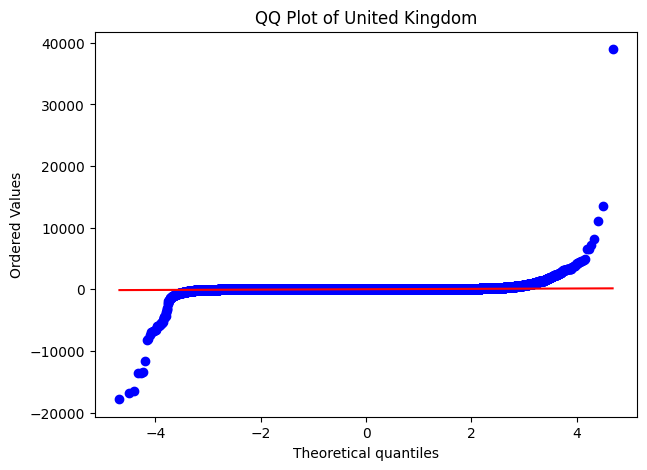

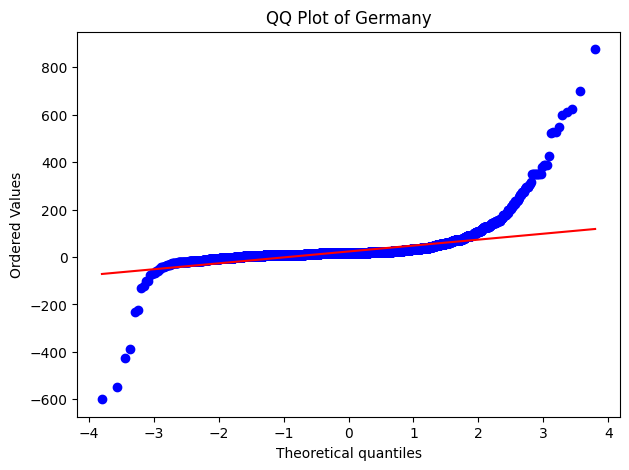

In [25]:
from scipy import stats
from scipy.stats import norm, probplot

# QQ plot(uk)
plt.figure(figsize=(7,5))
probplot(uk, dist="norm", plot=plt)
plt.title("QQ Plot of United Kingdom")
plt.show()

# QQ plot(germany)
plt.figure(figsize=(7,5))
probplot(germany, dist="norm", plot=plt)
plt.title("QQ Plot of Germany")
plt.show()

In [34]:
from scipy.stats import ttest_ind

t_stat, p_value = stats.ttest_ind(uk, germany, equal_var=False)

print(t_stat, p_value)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

-15.83833516328645 5.425039401232371e-56
T-statistic: -15.8383
P-value: 0.0000


미션 2에서는 주문 건수가 가장 많은 상위 두 국가인 영국(United Kingdom)과 독일(Germany)의 TotalPrice 평균 차이를 검증하기 위해 독립표본 t검정(Welch's t-test)을 수행하였다. 분석 수행 전에 두 국가의 TotalPrice 분포에 대한 정규성을 확인하기 위해 QQ-플롯을 시각화한 결과, 두 분포 모두 중간부분을 제외하고는 직선에서 좀 벗어나 있어 완전하게 정규분포를 따른다고는 말하기 어렵다. 이러한 경우 로그 변환 또는 비모수 검정을 고려할 수 있으나, 미션 2에서 쓰이는 데이터의 표본 크기(UK 약 49만 건, Germany 약 9천 건)가 매우 크기 때문에 중심극한정리에 의해 평균의 분포가 정규분포에 근사할 수 있으며, 이에 따라 t검정이 정규성 띄지 않아도 상대적으로 강건하다고 판단하여 미션 2에서 요청한 그대로 t검정을 수행하기로 결정했다.

귀무가설(H0)은 “두 국가의 평균 TotalPrice는 같다”이며, 대립가설(H1)은 “두 국가의 평균 TotalPrice는 다르다”로 설정하고 Welch t검정을 수행했다. 검정 결과, t통계량은 –15.88, p-value은 약 5.425×10^-56으로 나타났다. 출력 형식 제한으로 인해서 p-value가 0.0000으로 보이기도 했지만, 실제로는 0이 아니라 0에 매우 가까운 극도로 작은 값임을 출력 형식 제한하지 않았을 때는 확인 가능했다. 유의수준(a)=0.05 라는 가정 하에서 p-value가 매우 작으므로 귀무가설은 기각되었다. t통계량이 음수라는 점은 영국의 평균 TotalPrice가 독일보다 더 작다는 것을 의미하고, p-value가 0.05보다 압도적으로 작기 때문에 두 국가 간 평균 거래 금액 차이는 통계적으로 유의하다고 결론내릴 수 있었다.

또한 통계적 오류 관점에서 봤을 때는 이번 결과가 1종 오류(실제로 차이가 없는데 있다고 판단하는 오류)일 가능성이 매우 낮고, 이미 차이가 있다는 증거가 충분하므로 2종 오류(실제로 차이가 있는데 없다고 판단하는 오류) 상황에도 해당되지 않는다고 할 수 있다.

## 3. 주중, 주말에 따라서 발생하는 UnitPrice의 분포가 달라지는지 확인하세요.

* 주중의 'UnitPrice'와 주말의 'UnitPrice'의 분포를 분석하기 위해 데이터의 중심경향치(평균, 중간값), 변산성(표준편차, 분산), 분위수를 계산하세요.  
* 상자수염그림과 히스토그램을 그려 시각화를 통해 분포를 확인하고 데이터의 분포에 대해 설명해주세요.

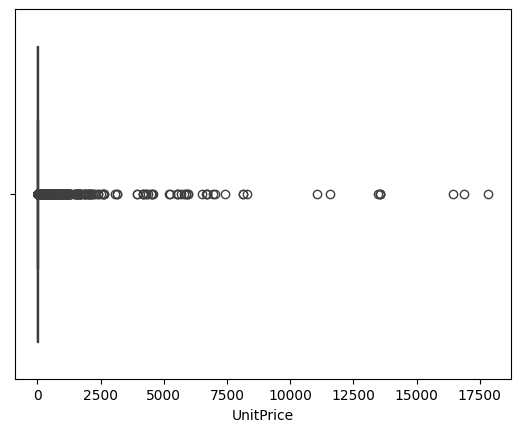

In [35]:
sns.boxplot(x=df['UnitPrice']);
plt.show()

In [36]:
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

weekday = df[df['IsWeekend'] == 0]['UnitPrice']
weekend = df[df['IsWeekend'] == 1]['UnitPrice']

In [42]:
stats_df = pd.concat({'Weekday': weekday.describe(), 'Weekend': weekend.describe()}, axis=1)
stats_df

,Weekday,Weekend
count,475017.000000,64370.000000
mean,4.833613,2.888049
std,83.425292,7.959766
min,0.001000,0.001000
25%,1.250000,1.250000
50%,2.100000,1.850000
75%,4.130000,3.750000
max,17836.460000,1236.750000


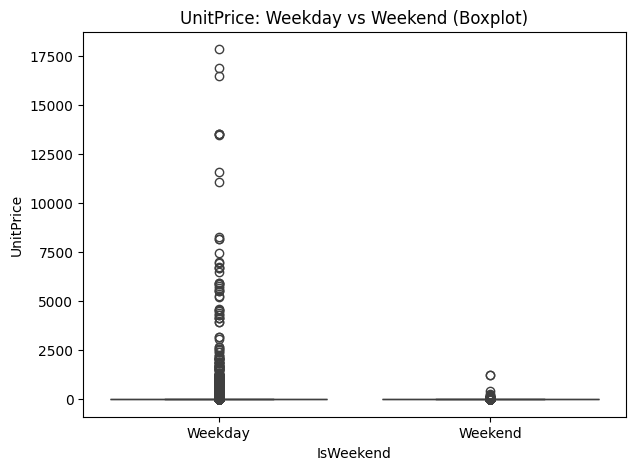

In [46]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['IsWeekend'], y=df['UnitPrice'])
plt.xticks([0,1], ['Weekday', 'Weekend'])
plt.title("UnitPrice: Weekday vs Weekend (Boxplot)")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


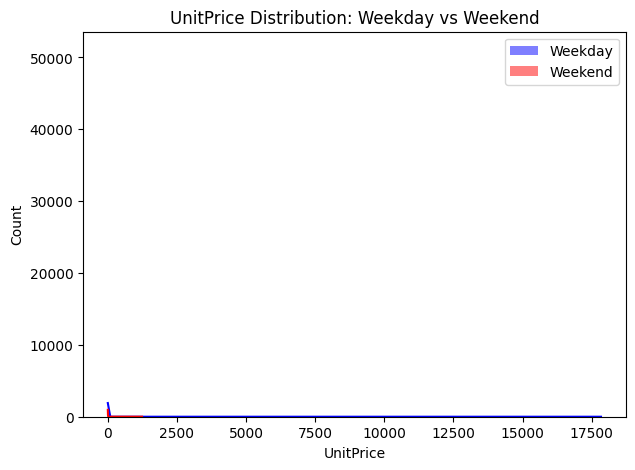

In [47]:
plt.figure(figsize=(7,5))
sns.histplot(weekday, color='blue', kde=True, label='Weekday', alpha=0.5)
sns.histplot(weekend, color='red',  kde=True, label='Weekend', alpha=0.5)
plt.title("UnitPrice Distribution: Weekday vs Weekend")
plt.legend()
plt.show()

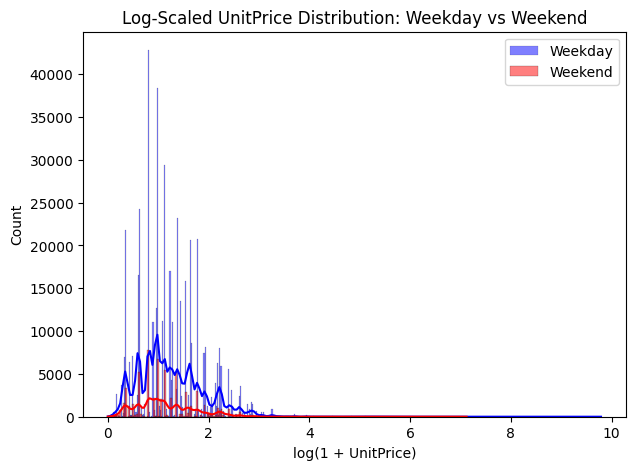

In [48]:
import numpy as np

plt.figure(figsize=(7,5))
sns.histplot(np.log1p(weekday), kde=True, label='Weekday', color='blue', alpha=0.5)
sns.histplot(np.log1p(weekend), kde=True, label='Weekend', color='red', alpha=0.5)
plt.title("Log-Scaled UnitPrice Distribution: Weekday vs Weekend")
plt.xlabel("log(1 + UnitPrice)")
plt.legend()
plt.show()

미션 3에서는 주중(평일)과 주말의 UnitPrice(단가) 분포를 비교하여 두 기간의 가격 패턴을 살펴봤다. 기술통계 결과를 보면, 평일의 평균 및 중앙값이 주말보다 다소 높게 나타났으며, 특히 최댓값에서 큰 차이를 보여 평일에 극단적으로 높은 가격대의 거래가 존재함을 확인할 수 있었다. 즉, 전반적인 가격대는 유사하지만, 평일에 고가 상품이 더 자주 거래되는 경향이 기술통계를 통해 볼 수 있었다.

박스플롯 분석에서도 동일한 패턴이 관찰되었다. 두 그룹 모두 가격이 낮은 범위에 밀집되어 있으며 위로 길게 꼬리를 갖는 비대칭 형태였고, 평일에 훨씬 높은 이상치들이 분포하는 것을 시각적으로 확인할 수 있었다. 이는 평일에 어느 정도 고가 판매건이 존재한다는 해석에 힘을 실어준다.

히스토그램을 이용한 분포 시각화에서는, 원본 스케일에서 극단값의 영향으로 대부분의 데이터가 매우 낮은 구간에 뭉쳐 나타났고, 사실상 분포 형태를 제대로 확인하기 어려웠다. 이러한 결과는 UnitPrice가 심하게 우측으로 퍼진 꼬리 구조임을 의미한다.

이 문제를 해소하기 위해 log(1 + UnitPrice) 변환을 적용하고 다시 시각화하였다. 로그 변환 후 히스토그램 및 KDE 곡선에서 두 분포의 형태가 명확하게 드러났으며, 두 그룹 모두 저가 상품이 주로 판매되는 경향을 나타냈다. 그러나 평일 분포는 주말보다 오른쪽 꼬리가 더 길고 범위가 넓어, 고가 상품 비중이 평일에 더 높다는 점이 보다 명확히 확인되었다. 이는 대량 고가 구매가 주말보다 평일 업무 시간에 발생하며 기업 간 거래라고도 추정해볼 수 있다.

즉, 주중과 주말의 상품 단가 분포는 전체적인 구조가 유사하며 모두 저가 상품 위주로 판매된다. 하지만, 극단적인 고가 거래의 발생률이 평일에 뚜렷하게 높다는 점이 기술통계, 박스플롯, 원본 히스토그램, 로그 변환 히스토그램 분석 전반에서 일관되게 나타났다. 따라서 “평균적인 판매 가격대는 비슷하지만, 고가 상품 구매는 주중에 더 빈번히 이루어지는 경향이 있다”고 결론 지어 본다.

## 4. 상품의 단가와 판매 국가, 판매 날짜을 이용해 판매 수량을 예측하는 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* 변수를 다음과 같이 설정하여 다중 선형 회귀 분석을 진행하세요.
    * 종속변수: 판매 수량(`Quantity`)
    * 독립변수: 상품 단가(`UnitPrice`), 판매 국가(`Country`), 판매 요일(`DayOfWeek`), 판매 월( `InvoiceMonth`)   
* 회귀계수와 결정계수를 활용하여 회귀 분석 결과를 해석해주세요.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 판매 데이터만 사용 (반품 제거)
sales = df[df['Quantity'] > 0].copy()

# 필요한 변수만 선택
sales = sales[['Quantity', 'UnitPrice', 'Country', 'DayOfWeek', 'InvoiceMonth']]

# 결측치 제거
sales = sales.dropna()

In [30]:
sales_encoded = pd.get_dummies(sales, columns=['Country', 'DayOfWeek'], drop_first=True)

In [31]:
X = sales_encoded.drop('Quantity', axis=1)
y = sales_encoded['Quantity']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [33]:
# 회귀계수
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("회귀계수:\n", coef_df)

# 결정계수 (R^2)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"\n결정계수 (R^2): {r2:.4f}")

회귀계수:
                          Feature  Coefficient
25           Country_Netherlands    12.416323
33                Country_Sweden     4.590308
21                 Country_Japan     2.792720
41                   DayOfWeek_3     2.219669
40                   DayOfWeek_2     1.505256
39                   DayOfWeek_1     0.827632
42                   DayOfWeek_4     0.492616
0                      UnitPrice    -0.014130
1                   InvoiceMonth    -0.026457
43                   DayOfWeek_6    -1.705405
9         Country_Czech Republic   -40.349952
31             Country_Singapore   -45.232779
23             Country_Lithuania   -49.248787
10               Country_Denmark   -49.942282
6                 Country_Canada   -50.911215
11                  Country_EIRE   -51.919146
26                Country_Norway   -52.905728
17             Country_Hong Kong   -53.966234
34           Country_Switzerland   -55.129928
13               Country_Finland   -55.239657
35                   Countr

## 5. 상품 정보와 거래 정보를 바탕으로 해당 거래가 반품될 가능성을 예측하는 로지스틱 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* `Quantity` 피쳐를 활용해 `IsReturn` 피쳐를 생성하세요.
* 모델 학습에 사용할 적절한 피쳐를 선정하세요.
* 모델 학습과 검증을 위해 데이터셋을 train셋과 test셋으로 나누세요.
* `IsReturn`을 예측하는 로지스틱 회귀 모델을 학습하세요.
* 혼동행렬, 정밀도, 재현율, F1-score 등 다양한 평가지표를 사용하여 모델의 성능을 평가하세요.
* 모델의 성능을 더 높일 수 있는 방안에 대해서 고민해보세요.

In [34]:
import pandas as pd
import numpy as np

# 원본에서 작업한다고 가정
data = df.copy()

# 반품 여부 정의
data['IsReturn'] = data['InvoiceNo'].str.startswith('C').astype(int)

# Quantity<0 & InvoiceNo not starting with C → 데이터 오류 제거
data = data[~((data['Quantity'] < 0) & (~data['InvoiceNo'].str.startswith('C')))]

# Quantity 절대값 변환 (모델 일관성을 위해)
data.loc[data['IsReturn'] == 1, 'Quantity'] = -data['Quantity']

# 필요 컬럼만 선택
model_df = data[['Quantity', 'UnitPrice', 'DayOfWeek', 'InvoiceMonth', 'Country', 'IsReturn']]
model_df = model_df.dropna()

In [35]:
model_df = pd.get_dummies(model_df, columns=['Country', 'DayOfWeek'], drop_first=True)

In [36]:
from sklearn.model_selection import train_test_split

X = model_df.drop('IsReturn', axis=1)
y = model_df['IsReturn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [38]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC: {auc:.4f}")

Confusion Matrix:
 [[106014      7]
 [  1851      6]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99    106021
           1       0.46      0.00      0.01      1857

    accuracy                           0.98    107878
   macro avg       0.72      0.50      0.50    107878
weighted avg       0.97      0.98      0.97    107878


ROC-AUC: 0.6014
